# Buzz Lightyear Bitacora, fecha 4072

**02:** En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

**03:** Se entrena una red para cada cuadrante y al final se usa un clasificador RBF con las probabilidades de las 4 redes como entradas.  
`ul: 50, ur: 50, ll: 40, lr: 40; RBF: 45`

**04:** No se si la maximizacion de la varianza ayude o no, se pone a prueba en esta notebook, se hace cropping de los cuadrantes, sin aplicar color jittering. Le hice 100 epocas para asegurarme que no fuera por eso, resulta que empeoro el rendimiento. Supongo que el problema es el cropping.  
 `ul: 55, ur: 45, ll: 40, lr: 40; RBF: 45`

**06:** Tengo que volver a encontrar la forma de maximizar la varianza, pero ahora sin hacer cropping. Chat me dijo que buscara entre 0, 0.6, no lei la clase, pero lo hice asi.

**07:** Me di cuenta que el ColorJittering solo es random, en esta notebook lo quite e intente nuevas formas, salieron peores resultados. Tambien cambie la forma de hacer el meta-modelo, ahora se fija en los TPR de cada clase y los usa como pesos para entrenar el meta-modelo RBF. Me pone feliz que al que mejor le fue, es el que tiene color jittering.  
`ul: 45, ur: 40, ll: 50, lr: 40; RBF: 35`.

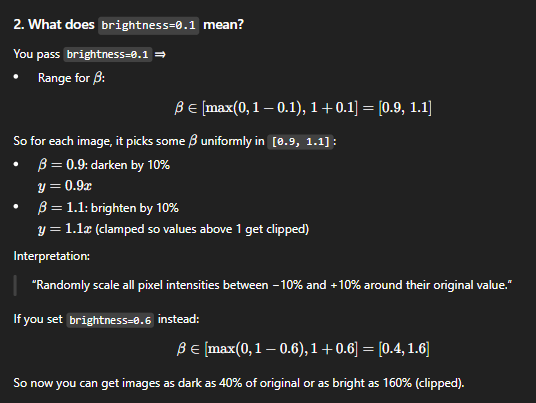

**08:** En esta notebook se vuelve a poner el ColorJittering, me pesaba no saber que hacia. No hice normalizacion, tome la imagen completa. Me doy cuenta que cuando haces los crops, el training llega a 100% muy rapido, pero generaliza mal; al tomar la imagen completa, tarda mas en llegar a 100% pero generaliza mejor. JAJAJAAJJ me da mucha risa que desde que le puse cuadrantes he estade pensando en la peli, Cuadrante Gamma del Sector 4!  
`ul: 55, ur: 55, ll: 45, lr: 45; RBF: 40`.   


**09:** Vale la pena normalizar? Mucho, si. Creo que sigo cargando desbalance de clases.  
`ul: 50, ur: 50, ll: 50, lr: 60; RBF: 40`

**10:** Un Pullock es igual si esta vertical u horizontal, tambien si tiene un flip. QUE?! PASO TODO LO CONTRARIO!

**11:** Se sobreajusta. Voy a intentar con Dropout y BatchNorm. Tambien voy a intentar con un learning rate mas bajo. Un dropout quiere decir que en cada iteracion, se apagan algunas neuronas al azar, para que la red no dependa tanto de ciertas neuronas. BatchNorm normaliza las activaciones de cada capa, para que no se disparen mucho. Un BatchNorm puede ayudar a que el entrenamiento sea mas estable y rapido, este se hace mediante la normalizacion de las activaciones de cada capa.

# Loading the DataSet

In [1]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [2]:
painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

In [3]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [4]:
print(df['genre'].value_counts())
df.head()

genre
Impresionismo              75
Surrealismo                50
Barroco                    30
Cubismo                    30
Expresionismo abstracto    15
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4


In [5]:
from PIL import Image
import os

# Create the data_augmented folder if it doesn't exist
augmented_dir = "08 Clasificacion de Movimientos Artisticos/data_augmented"
os.makedirs(augmented_dir, exist_ok=True)

# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Expresionismo abstracto':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(90, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        rotated = img.rotate(180)
        new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")

# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Cubismo':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(90, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")

# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Barroco':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        base, ext = os.path.splitext(os.path.basename(img_path))
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")


for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Surrealismo':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(180, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")

Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_1_rotated90.jpg
Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_1_rotated180.jpg
Saved flipped image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_1_flipped.jpg
Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_10_rotated90.jpg
Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_10_rotated180.jpg
Saved flipped image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_10_flipped.jpg
Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_11_rotated90.jpg
Saved rotated image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pollock_11_rotated180.jpg
Saved flipped image to 08 Clasificacion de Movimientos Artisticos/data_augmented\Jackson_Pol

In [6]:
from pathlib import Path
import pandas as pd

root2 = Path("08 Clasificacion de Movimientos Artisticos/data_augmented")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root2.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df2 = pd.DataFrame(rows)

In [7]:
# concatena los dos dataframes
df = pd.concat([df, df2], ignore_index=True)
print(df['genre'].value_counts())
df.head()

genre
Surrealismo                100
Impresionismo               75
Barroco                     60
Expresionismo abstracto     60
Cubismo                     60
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4


In [8]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y


# Data Engineering 😜

## maximize variance

In [9]:
import torch
from PIL import Image

def compute_mean_std_from_df(df, transform):
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for path in df["path"]:
        img = Image.open(path).convert("RGB")
        x = transform(img)           # C×H×W, in [0,1]

        B, C, H, W = 1, *x.shape     # fake batch size 1
        n = B * H * W

        channel_sum    += x.view(C, -1).sum(dim=1)
        channel_sq_sum += (x**2).view(C, -1).sum(dim=1)
        n_pixels       += n

    mean = channel_sum / n_pixels
    var  = channel_sq_sum / n_pixels - mean ** 2
    std  = torch.sqrt(var + 1e-8)
    return mean, std

In [10]:
from torchvision import transforms

transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.75, saturation=0.75, brightness=0.75, hue=0.5),
    transforms.ToTensor(),
    # get the mean and std for normalization
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=0.99, saturation=0.99, brightness=0.99, hue=0),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.5, saturation=0.5, brightness=0.5, hue=0.2),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.99, saturation=0.5, brightness=0.1, hue=0.2),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(df, transf_ul)
mean_ur, std_ur = compute_mean_std_from_df(df, transf_ur)
mean_ll, std_ll = compute_mean_std_from_df(df, transf_ll)
mean_lr, std_lr = compute_mean_std_from_df(df, transf_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.24, saturation=0.24, brightness=0.24, hue=0),
    transforms.ToTensor(),
    # get the mean and std for normalization
    transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=0.99, saturation=0.99, brightness=0.99, hue=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.5, saturation=0.5, brightness=0.5, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=0.99, saturation=0.5, brightness=0.1, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])

UL: tensor([0.4068, 0.4048, 0.4127]) tensor([0.2905, 0.2918, 0.2912])
UR: tensor([0.4389, 0.4027, 0.3573]) tensor([0.3283, 0.3189, 0.3117])
LL: tensor([0.4544, 0.4166, 0.3697]) tensor([0.2735, 0.2757, 0.2600])
LR: tensor([0.4637, 0.4229, 0.3809]) tensor([0.2549, 0.2541, 0.2424])


# Transfarmation and split train and validation sets

In [11]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=863)

In [12]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=transf_ur)
train_ll = PaintingDataset(train_df, transform=transf_ll)
train_lr = PaintingDataset(train_df, transform=transf_lr)

val_ul = PaintingDataset(val_df, transform=transf_ul)
val_ur = PaintingDataset(val_df, transform=transf_ur)
val_ll = PaintingDataset(val_df, transform=transf_ll)
val_lr = PaintingDataset(val_df, transform=transf_lr)

In [13]:
import torch.utils.data
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur, train_ll, train_lr])
val_ds = torch.utils.data.ConcatDataset([val_ul, val_ur, val_ll, val_lr])

# Visualización de imágenes con los mejores parámetros encontrados

Label: 2 Expresionismo abstracto


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2690684..2.0150647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3368944..-0.982628].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.661449..0.59937966].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4654305..1.2988484].


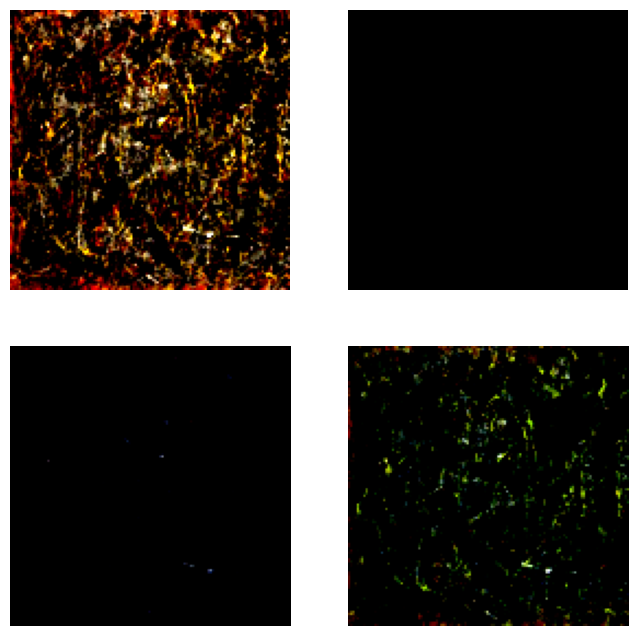

In [14]:
import random
r = random.randint(0, len(train_ul)-1)

img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()


# ReLU

In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [16]:
import numpy as np
import torch

NUM_CLASSES = len(genre_to_label)

# labels must be integers 0..C-1 (you already have that)
labels_train = train_df["label"].values  # shape (N_train,)

# counts per class, ordered by label index
class_counts = np.bincount(labels_train, minlength=NUM_CLASSES).astype(float)
print("class_counts:", class_counts)

# inverse-frequency weights (rarer classes get higher weight)
class_weights = 1.0 / class_counts
# optional: normalize so average weight ~1
class_weights = class_weights * (NUM_CLASSES / class_weights.sum())
print("class_weights:", class_weights)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


class_counts: [90. 54. 54. 54. 67.]
class_weights: [0.68089431 1.13482385 1.13482385 1.13482385 0.91463415]


In [17]:
# Dicts to refer to quadrant datasets by name
quadrant_train_ds = {
    "ul": train_ul,
    "ur": train_ur,
    "ll": train_ll,
    "lr": train_lr,
}
quadrant_val_ds = {
    "ul": val_ul,
    "ur": val_ur,
    "ll": val_ll,
    "lr": val_lr,
}

# Also keep transforms in a dict (for later inference/meta features)
transforms_quadrant = {
    "ul": transf_ul,
    "ur": transf_ur,
    "ll": transf_ll,
    "lr": transf_lr,
}

In [18]:
import torch.nn as nn

NUM_CLASSES = len(genre_to_label)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 3, 128, 128)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 32 -> 16

            nn.AdaptiveAvgPool2d((1, 1)),  # -> (B, 128, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),             # (B, 128)
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)  # convolution + pooling + avgpool
        x = self.classifier(x)
        return x


In [19]:
# Training loop for a single model
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch.optim import Adam
from tqdm import tqdm

def train_one_model(train_loader, val_loader, num_epochs=10, lr=1e-3,
                    class_weights=None):
    model = SmallCNN().to(device)
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_state   = None
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)   # <- weighted CE
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---- validation (unweighted metrics) ----
        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)  # still weighted for loss

                val_loss += loss.item() * imgs.size(0)
                _, preds = logits.max(1)
                val_total   += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    print("Best val_acc (CNN):", best_val_acc)
    return model, history




In [20]:
# Train one model per quadrant
BATCH_SIZE = 32

models_quadrant   = {}
histories_quadrant = {}

for qname in ["ul", "ur", "ll", "lr"]:
    print(f"\n===== Training quadrant: {qname} =====")

    train_ld_q = DataLoader(
        quadrant_train_ds[qname],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    val_ld_q = DataLoader(
        quadrant_val_ds[qname],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model_q, hist_q = train_one_model(
        train_loader=train_ld_q,
        val_loader=val_ld_q,
        num_epochs=20,
        lr=1e-3,
        class_weights=class_weights_t,   # <- HERE
    )

    models_quadrant[qname] = model_q
    histories_quadrant[qname] = hist_q



===== Training quadrant: ul =====


Epoch 01 | train_loss=1.6045, train_acc=0.270 | val_loss=1.5814, val_acc=0.278


Epoch 02 | train_loss=1.5620, train_acc=0.270 | val_loss=1.5541, val_acc=0.222


Epoch 03 | train_loss=1.4566, train_acc=0.376 | val_loss=1.4914, val_acc=0.278


Epoch 04 | train_loss=1.4306, train_acc=0.313 | val_loss=1.3525, val_acc=0.389


...

Epoch 16 | train_loss=1.0132, train_acc=0.520 | val_loss=1.0777, val_acc=0.361


Epoch 17 | train_loss=0.9989, train_acc=0.527 | val_loss=1.3171, val_acc=0.333


Epoch 18 | train_loss=1.0485, train_acc=0.483 | val_loss=1.0779, val_acc=0.500


Epoch 19 | train_loss=0.9584, train_acc=0.517 | val_loss=0.9494, val_acc=0.528


Epoch 20 | train_loss=0.9493, train_acc=0.545 | val_loss=1.0241, val_acc=0.472
Best val_acc (CNN): 0.5277777777777778


In [21]:
# Build meta-dataset: stacked probabilities from the 4 models
import numpy as np

def build_meta_dataset(df_subset, models_quadrant, transforms_quadrant,
                       batch_size=32):
    quadrant_names = list(models_quadrant.keys())

    # create one dataset / loader per quadrant on this subset
    datasets_q = {
        q: PaintingDataset(df_subset, transform=transforms_quadrant[q])
        for q in quadrant_names
    }
    loaders_q = {
        q: DataLoader(
            datasets_q[q],
            batch_size=batch_size,
            shuffle=False,    # must preserve order
            num_workers=0,
            pin_memory=True,
        )
        for q in quadrant_names
    }

    probs_q = {q: [] for q in quadrant_names}
    labels_all = []

    with torch.no_grad():
        for qi, q in enumerate(quadrant_names):
            model_q = models_quadrant[q].to(device)
            model_q.eval()

            first_q = (qi == 0)

            for imgs, labels in loaders_q[q]:
                imgs = imgs.to(device, non_blocking=True)
                logits = model_q(imgs)                # (B, C)
                probs = torch.softmax(logits, dim=1)  # (B, C)

                probs_q[q].append(probs.cpu())
                if first_q:
                    labels_all.append(labels.clone())

    probs_q_cat = [torch.cat(probs_q[q], dim=0) for q in quadrant_names]  # each (N,C)
    X_meta = torch.cat(probs_q_cat, dim=1).numpy()  # (N, Q*C)
    y_meta = torch.cat(labels_all, dim=0).numpy()   # (N,)

    return X_meta, y_meta

X_train_meta, y_train_meta = build_meta_dataset(
    train_df, models_quadrant, transforms_quadrant, batch_size=BATCH_SIZE
)
X_val_meta,   y_val_meta   = build_meta_dataset(
    val_df, models_quadrant, transforms_quadrant, batch_size=BATCH_SIZE
)

print("X_train_meta shape:", X_train_meta.shape)  # (N_train, 4 * NUM_CLASSES)
print("X_val_meta   shape:", X_val_meta.shape)


X_train_meta shape: (319, 20)
X_val_meta   shape: (36, 20)


# Meta RBF

In [22]:
# RBF meta-classifier on top of stacked probabilities
from sklearn.cluster import KMeans

def init_rbf_centers(X_train_meta, n_centers=20, random_state=42):
    kmeans = KMeans(
        n_clusters=n_centers,
        random_state=random_state,
        n_init="auto"
    )
    kmeans.fit(X_train_meta)
    return kmeans.cluster_centers_

class RBFMeta(nn.Module):
    def __init__(self, in_dim, num_classes, centers, gamma=None, train_gamma=False):
        super().__init__()
        centers = torch.tensor(centers, dtype=torch.float32)
        self.register_buffer("centers", centers)  # (K, D)
        self.K, self.in_dim = centers.shape

        if gamma is None:
            with torch.no_grad():
                c = centers
                dist2 = torch.cdist(c, c, p=2.0) ** 2  # (K,K)
                median_dist2 = torch.median(dist2)
                gamma_val = 1.0 / (2.0 * median_dist2.clamp(min=1e-6))
        else:
            gamma_val = float(gamma)

        if train_gamma:
            self.gamma = nn.Parameter(torch.tensor(gamma_val))
        else:
            self.register_buffer("gamma", torch.tensor(gamma_val))

        self.linear = nn.Linear(self.K, num_classes)

    def forward(self, x):
        # x: (N, D)
        x_expanded = x.unsqueeze(1)           # N x 1 x D
        c_expanded = self.centers.unsqueeze(0)  # 1 x K x D
        dist2 = torch.sum((x_expanded - c_expanded) ** 2, dim=2)  # N x K
        phi = torch.exp(-self.gamma * dist2)  # N x K
        logits = self.linear(phi)             # N x num_classes
        return logits

def train_rbf_meta(X_train, y_train, X_val, y_val,
                   n_centers=20, num_epochs=100, lr=1e-3,
                   class_weights=None):

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long).to(device)

    centers = init_rbf_centers(X_train, n_centers=n_centers)
    model = RBFMeta(
        in_dim=X_train.shape[1],
        num_classes=NUM_CLASSES,
        centers=centers,
        gamma=None,
        train_gamma=False,
    ).to(device)

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            _, pred_train = logits.max(1)
            train_acc = (pred_train == y_train_t).float().mean().item()

            model.eval()
            logits_val = model(X_val_t)
            val_loss = criterion(logits_val, y_val_t).item()
            _, pred_val = logits_val.max(1)
            val_acc = (pred_val == y_val_t).float().mean().item()

        print(f"[RBF] Epoch {epoch+1:03d} | "
              f"train_loss={loss.item():.4f}, train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)
    print("Best val_acc (RBF meta):", best_val_acc)

    return model


In [23]:
def predict_weighted_probs(img, models_quadrant, transforms_quadrant, alpha):
    # alpha: dict {"ul": α_ul, ...}
    probs_total = None

    with torch.no_grad():
        for q, model_q in models_quadrant.items():
            x_q = transforms_quadrant[q](img).unsqueeze(0).to(device)
            logits_q = model_q.to(device)(x_q)
            p_q = torch.softmax(logits_q, dim=1).cpu()  # 1×C

            w = alpha[q]
            if probs_total is None:
                probs_total = w * p_q
            else:
                probs_total += w * p_q

    probs_total = probs_total / probs_total.sum(dim=1, keepdim=True)
    pred = probs_total.argmax(dim=1).item()
    return pred, probs_total.numpy()[0]

# get best val accuracy per quadrant
acc_quadrant = {}
for q in ["ul", "ur", "ll", "lr"]:
    hist = histories_quadrant[q]
    best_val = max(hist["val_acc"])
    acc_quadrant[q] = best_val

print(acc_quadrant)

# e.g. α_q = best_val_acc / sum(best_val_acc)
sum_acc = sum(acc_quadrant.values())
alpha = {q: acc_quadrant[q] / sum_acc for q in acc_quadrant}
print("alpha (weights):", alpha)

def build_meta_dataset_weighted(df_subset, models_quadrant, transforms_quadrant,
                                alpha, batch_size=32):
    quadrant_names = list(models_quadrant.keys())

    datasets_q = {
        q: PaintingDataset(df_subset, transform=transforms_quadrant[q])
        for q in quadrant_names
    }
    loaders_q = {
        q: DataLoader(
            datasets_q[q],
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )
        for q in quadrant_names
    }

    probs_q = {q: [] for q in quadrant_names}
    labels_all = []

    with torch.no_grad():
        for qi, q in enumerate(quadrant_names):
            model_q = models_quadrant[q].to(device)
            model_q.eval()
            first_q = (qi == 0)

            for imgs, labels in loaders_q[q]:
                imgs = imgs.to(device, non_blocking=True)
                logits = model_q(imgs)
                probs = torch.softmax(logits, dim=1).cpu()  # (B, C)

                # multiply by quadrant weight α_q
                probs_q[q].append(alpha[q] * probs)

                if first_q:
                    labels_all.append(labels.clone())

    probs_q_cat = [torch.cat(probs_q[q], dim=0) for q in quadrant_names]  # each (N, C)
    X_meta = torch.cat(probs_q_cat, dim=1).numpy()  # (N, Q*C)
    y_meta = torch.cat(labels_all, dim=0).numpy()

    return X_meta, y_meta


{'ul': 0.6388888888888888, 'ur': 0.5, 'll': 0.5555555555555556, 'lr': 0.5277777777777778}
alpha (weights): {'ul': 0.2875, 'ur': 0.22499999999999998, 'll': 0.25, 'lr': 0.2375}


In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

NUM_CLASSES = len(genre_to_label)
quadrant_names = ["ul", "ur", "ll", "lr"]

tpr_quadrant = {}

for q in quadrant_names:
    print(f"Computing TPR for quadrant: {q}")
    ds = quadrant_val_ds[q]
    loader = DataLoader(
        ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    all_preds = []
    all_labels = []

    model_q = models_quadrant[q].to(device)
    model_q.eval()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model_q(imgs)
            _, preds = logits.max(1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    # TPR_c = CM[c,c] / sum_j CM[c,j]
    denom = cm.sum(axis=1).clip(min=1)  # avoid division by zero
    tpr = cm.diagonal() / denom

    print("Confusion matrix:\n", cm)
    print("TPR:", tpr)

    tpr_quadrant[q] = tpr  # numpy array shape (C,)


def build_meta_dataset_tprweighted(df_subset, models_quadrant, transforms_quadrant,
                                   tpr_quadrant, batch_size=32):
    """
    Returns:
        X_meta: (N, Q*C) with entries TPR_{q,c} * p_{q,c}(x_i)
        y_meta: (N,)
    """
    quadrant_names = list(models_quadrant.keys())

    # one dataset/loader per quadrant
    datasets_q = {
        q: PaintingDataset(df_subset, transform=transforms_quadrant[q])
        for q in quadrant_names
    }
    loaders_q = {
        q: DataLoader(
            datasets_q[q],
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )
        for q in quadrant_names
    }

    probs_q = {q: [] for q in quadrant_names}
    labels_all = []

    with torch.no_grad():
        for qi, q in enumerate(quadrant_names):
            model_q = models_quadrant[q].to(device)
            model_q.eval()
            first_q = (qi == 0)

            # convert TPR for this quadrant to tensor on CPU
            tpr_vec = torch.tensor(tpr_quadrant[q], dtype=torch.float32)  # (C,)

            for imgs, labels in loaders_q[q]:
                imgs = imgs.to(device, non_blocking=True)
                logits = model_q(imgs)
                probs = torch.softmax(logits, dim=1).cpu()  # (B, C)

                # weight by per-class TPR: (B,C) * (C,) -> (B,C)
                weighted = probs * tpr_vec.view(1, -1)

                probs_q[q].append(weighted)
                if first_q:
                    labels_all.append(labels.clone())

    # concatenate batches for each quadrant
    probs_q_cat = [torch.cat(probs_q[q], dim=0) for q in quadrant_names]  # each (N, C)
    # concatenate quadrants along feature dimension
    X_meta = torch.cat(probs_q_cat, dim=1).numpy()  # (N, Q*C)
    y_meta = torch.cat(labels_all, dim=0).numpy()   # (N,)

    return X_meta, y_meta






Computing TPR for quadrant: ul
Confusion matrix:
 [[1 1 0 1 7]
 [2 1 1 1 1]
 [0 0 6 0 0]
 [1 0 0 5 0]
 [0 0 3 1 4]]
TPR: [0.1        0.16666667 1.         0.83333333 0.5       ]
Computing TPR for quadrant: ur
Confusion matrix:
 [[2 1 0 2 5]
 [0 2 0 2 2]
 [0 0 4 1 1]
 [0 0 0 4 2]
 [0 0 0 4 4]]
TPR: [0.2        0.33333333 0.66666667 0.66666667 0.5       ]
Computing TPR for quadrant: ll
Confusion matrix:
 [[6 0 0 0 4]
 [0 1 1 3 1]
 [0 0 6 0 0]
 [1 1 0 4 0]
 [1 1 0 1 5]]
TPR: [0.6        0.16666667 1.         0.66666667 0.625     ]
Computing TPR for quadrant: lr
Confusion matrix:
 [[1 0 0 2 7]
 [0 0 0 3 3]
 [0 0 6 0 0]
 [1 0 0 5 0]
 [1 1 1 1 4]]
TPR: [0.1        0.         1.         0.83333333 0.5       ]


In [25]:
X_train_meta, y_train_meta = build_meta_dataset_tprweighted(
    train_df,
    models_quadrant,
    transforms_quadrant,
    tpr_quadrant,
    batch_size=BATCH_SIZE,
)

X_val_meta, y_val_meta = build_meta_dataset_tprweighted(
    val_df,
    models_quadrant,
    transforms_quadrant,
    tpr_quadrant,
    batch_size=BATCH_SIZE,
)

print("X_train_meta shape:", X_train_meta.shape)  # (N_train, 4*C)
print("X_val_meta shape:",   X_val_meta.shape)

X_train_meta shape: (319, 20)
X_val_meta shape: (36, 20)


In [26]:
rbf_meta_model = train_rbf_meta(
    X_train_meta, y_train_meta,
    X_val_meta,   y_val_meta,
    n_centers=20,
    num_epochs=100,
    lr=1e-3,
    class_weights=class_weights_t,  # if you still use imbalance weights
)

c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\herie\AppData\Local\Temp\ipykernel_22336\3513866009.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("gamma", torch.tensor(gamma_val))


[RBF] Epoch 001 | train_loss=1.5714, train_acc=0.414 | val_loss=1.5886, val_acc=0.417
[RBF] Epoch 002 | train_loss=1.5670, train_acc=0.423 | val_loss=1.5843, val_acc=0.417
[RBF] Epoch 003 | train_loss=1.5627, train_acc=0.436 | val_loss=1.5801, val_acc=0.417
[RBF] Epoch 004 | train_loss=1.5585, train_acc=0.439 | val_loss=1.5760, val_acc=0.417
[RBF] Epoch 005 | train_loss=1.5545, train_acc=0.442 | val_loss=1.5720, val_acc=0.417
[RBF] Epoch 006 | train_loss=1.5505, train_acc=0.445 | val_loss=1.5681, val_acc=0.417
[RBF] Epoch 007 | train_loss=1.5467, train_acc=0.445 | val_loss=1.5644, val_acc=0.417
[RBF] Epoch 008 | train_loss=1.5429, train_acc=0.445 | val_loss=1.5607, val_acc=0.417
[RBF] Epoch 009 | train_loss=1.5392, train_acc=0.445 | val_loss=1.5571, val_acc=0.417
[RBF] Epoch 010 | train_loss=1.5356, train_acc=0.445 | val_loss=1.5536, val_acc=0.417
[RBF] Epoch 011 | train_loss=1.5321, train_acc=0.445 | val_loss=1.5502, val_acc=0.417
[RBF] Epoch 012 | train_loss=1.5286, train_acc=0.445 |

In [27]:
# ------------------------------------------------------------------
# 7) Inference: full pipeline for a new image
# ------------------------------------------------------------------
from PIL import Image

inv_genre = {v: k for k, v in genre_to_label.items()}

def predict_full_pipeline(img_path, models_quadrant, transforms_quadrant,
                          tpr_quadrant, rbf_meta_model):
    img = Image.open(img_path).convert("RGB")
    quadrant_names = list(models_quadrant.keys())
    weighted_probs_all = []

    with torch.no_grad():
        for q in quadrant_names:
            # base probs from quadrant q
            x_q = transforms_quadrant[q](img)   # C×H×W
            x_q = x_q.unsqueeze(0).to(device)

            model_q = models_quadrant[q].to(device)
            model_q.eval()
            logits_q = model_q(x_q)
            probs_q = torch.softmax(logits_q, dim=1).cpu()  # 1×C

            # TPR weights for this quadrant
            tpr_vec = torch.tensor(tpr_quadrant[q], dtype=torch.float32).view(1, -1)
            weighted_q = probs_q * tpr_vec  # 1×C

            weighted_probs_all.append(weighted_q)

        # concatenate quadrants -> 1×(Q*C)
        feat = torch.cat(weighted_probs_all, dim=1).to(device)

        rbf_meta_model.eval()
        logits_meta = rbf_meta_model(feat)
        probs_meta = torch.softmax(logits_meta, dim=1)  # 1×C
        pred_idx = torch.argmax(probs_meta, dim=1).item()

    return pred_idx, probs_meta.cpu().numpy()[0]


# Visualización del modelo

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()

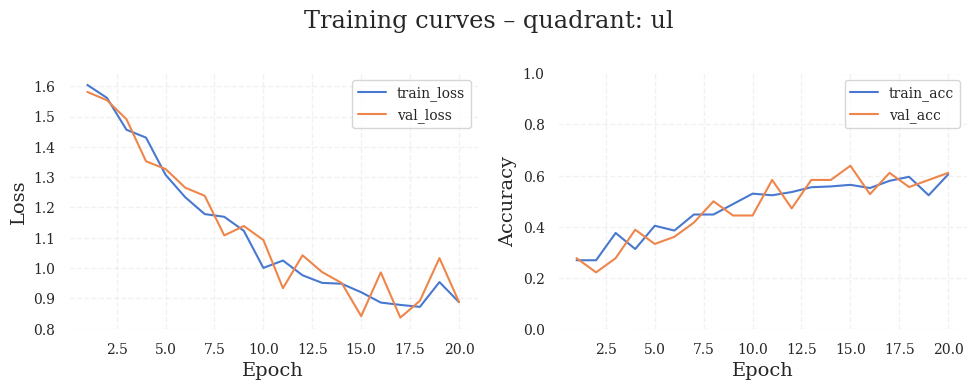

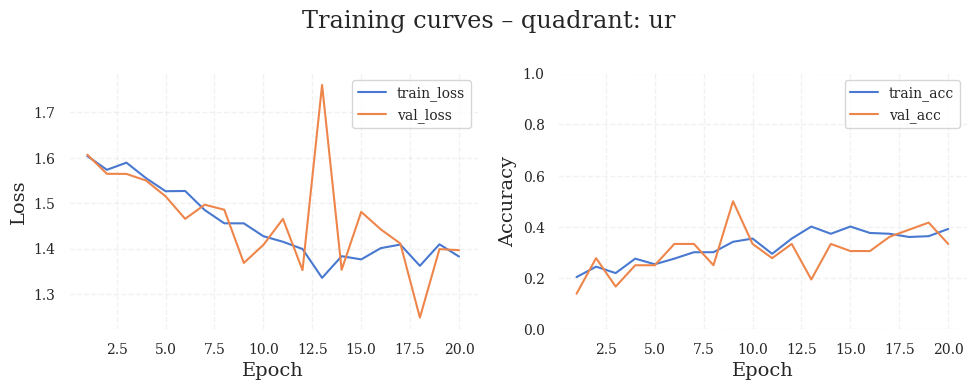

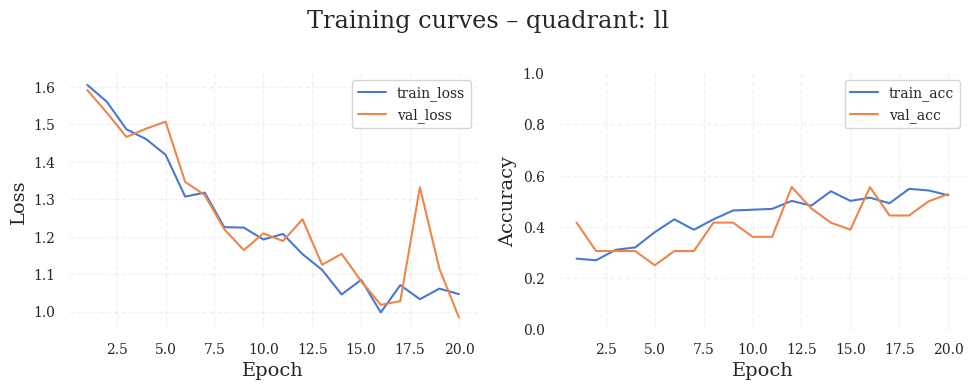

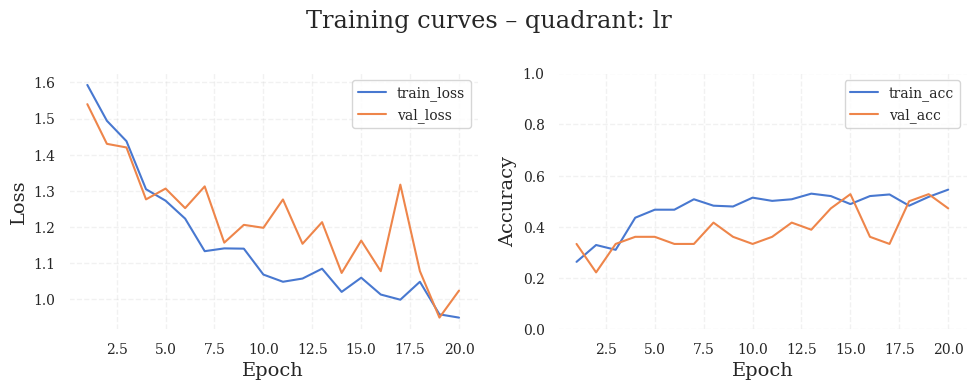

In [29]:
import matplotlib.pyplot as plt

quadrant_names = ["ul", "ur", "ll", "lr"]

for q in quadrant_names:
    hist = histories_quadrant[q]
    epochs = range(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Training curves – quadrant: {q}")

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["train_loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"],   label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Accuracy ---
    if "train_acc" in hist:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist["train_acc"], label="train_acc")
        plt.plot(epochs, hist["val_acc"],   label="val_acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0.0, 1.0)
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        # fallback if you didn't re-train with train_acc stored
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist["val_acc"], label="val_acc")
        plt.xlabel("Epoch")
        plt.ylabel("Val accuracy")
        plt.ylim(0.0, 1.0)
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [30]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

inv_genre = {v: k for k, v in genre_to_label.items()}
quadrant_names = ["ul", "ur", "ll", "lr"]
import matplotlib.pyplot as plt

inv_genre = {v: k for k, v in genre_to_label.items()}
quadrant_names = ["ul", "ur", "ll", "lr"]

def show_quadrant_probs(img_path, models_quadrant, transforms_quadrant):
    img = Image.open(img_path).convert("RGB")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f"Quadrant Analysis for {img_path.split('/')[-1]}")

    for i, q in enumerate(quadrant_names):
        # apply transform for this quadrant (includes crop + resize + normalize)
        x_q = transforms_quadrant[q](img)        # C x H x W
        x_vis = x_q.clone()

        # for visualization: un-normalize using that quadrant's mean/std if you want
        # but simplest: just use raw (might look slightly off colors)
        x_vis = x_vis.permute(1, 2, 0).numpy()
        x_vis = np.clip(x_vis, 0, 1)

        # Image in top row
        axes[0, i].imshow(x_vis)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"Quadrant view: {q}")

        # model prediction
        model_q = models_quadrant[q].to(device)
        model_q.eval()

        with torch.no_grad():
            x_batch = x_q.unsqueeze(0).to(device)
            logits = model_q(x_batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]  # shape (C,)

        # Bar plot in bottom row
        axes[1, i].bar(range(len(probs)), probs)
        axes[1, i].set_xticks(range(len(probs)))
        axes[1, i].set_xticklabels([inv_genre[j] for j in range(len(probs))], rotation=45, ha="right")
        axes[1, i].set_ylim(0, 1)
        axes[1, i].set_title(f"Probabilities for quadrant {q}")

    plt.tight_layout()
    plt.show()


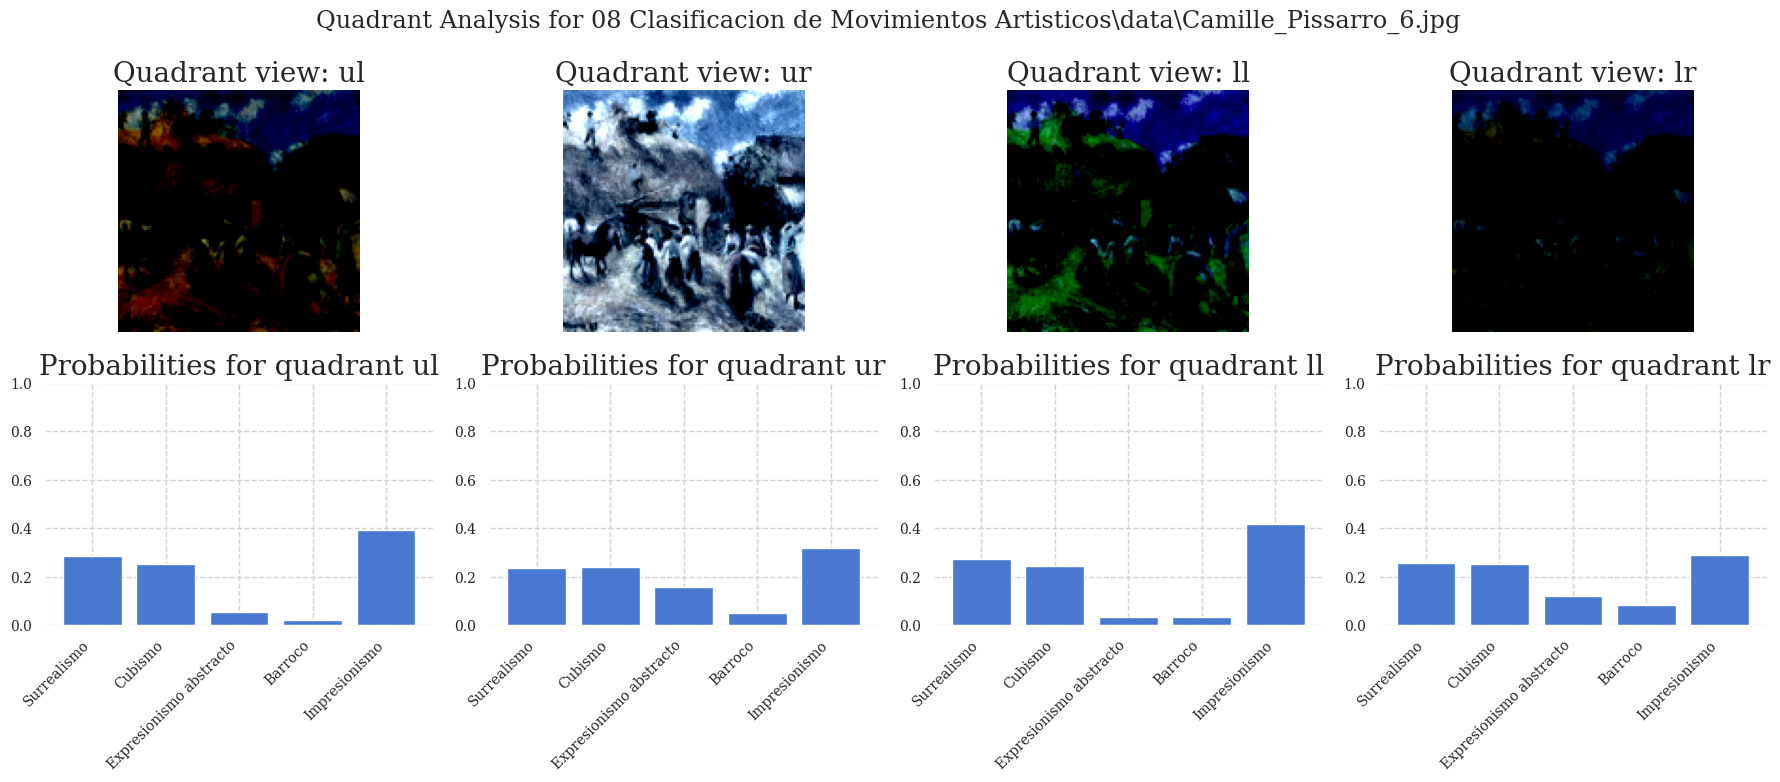

In [31]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

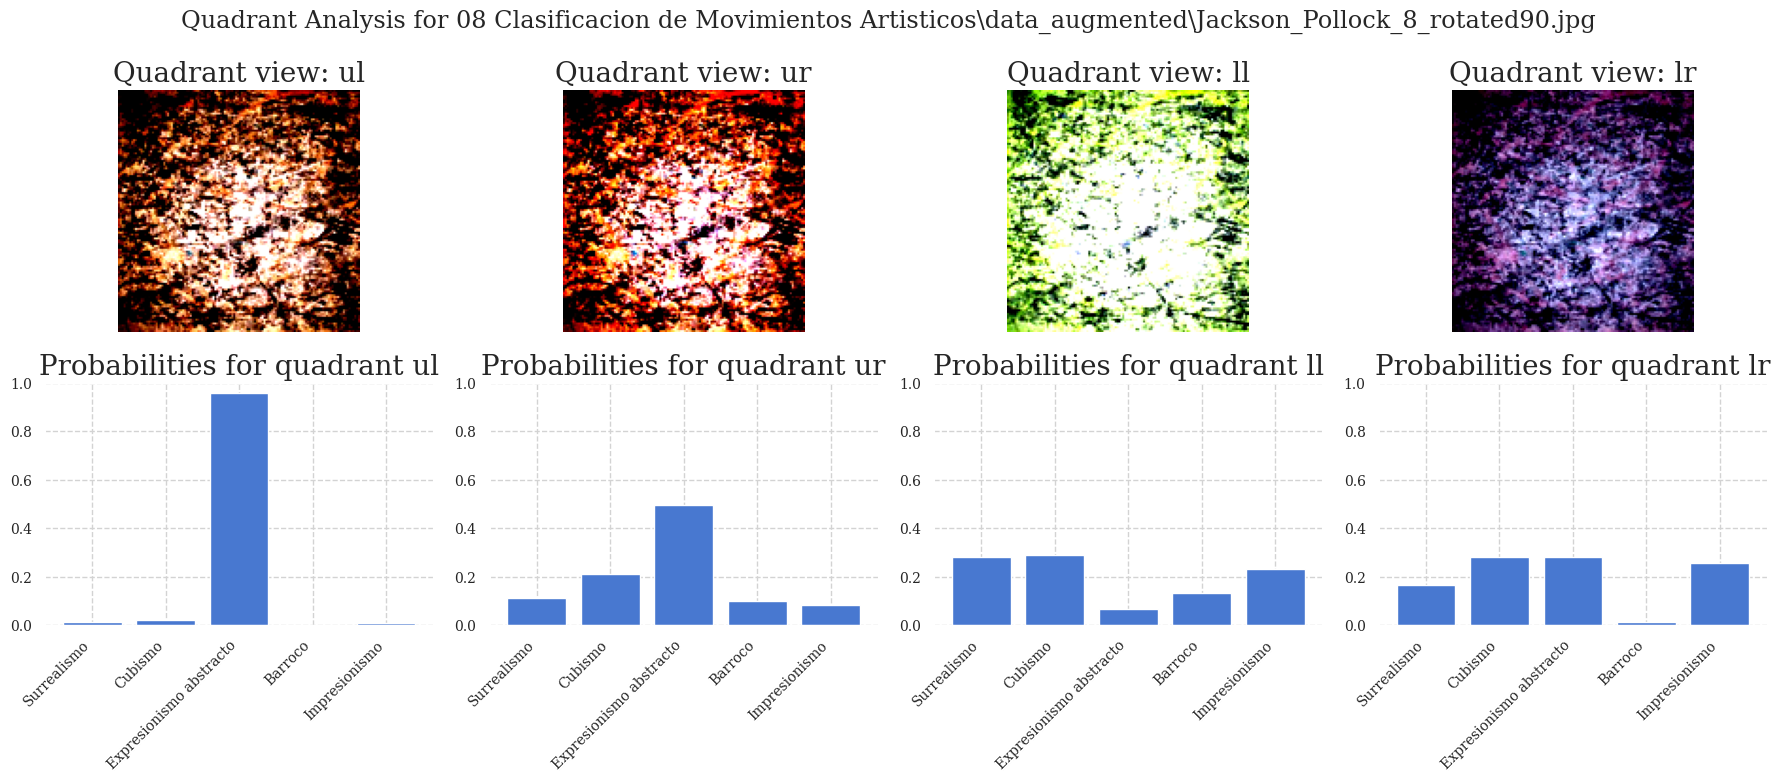

In [32]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

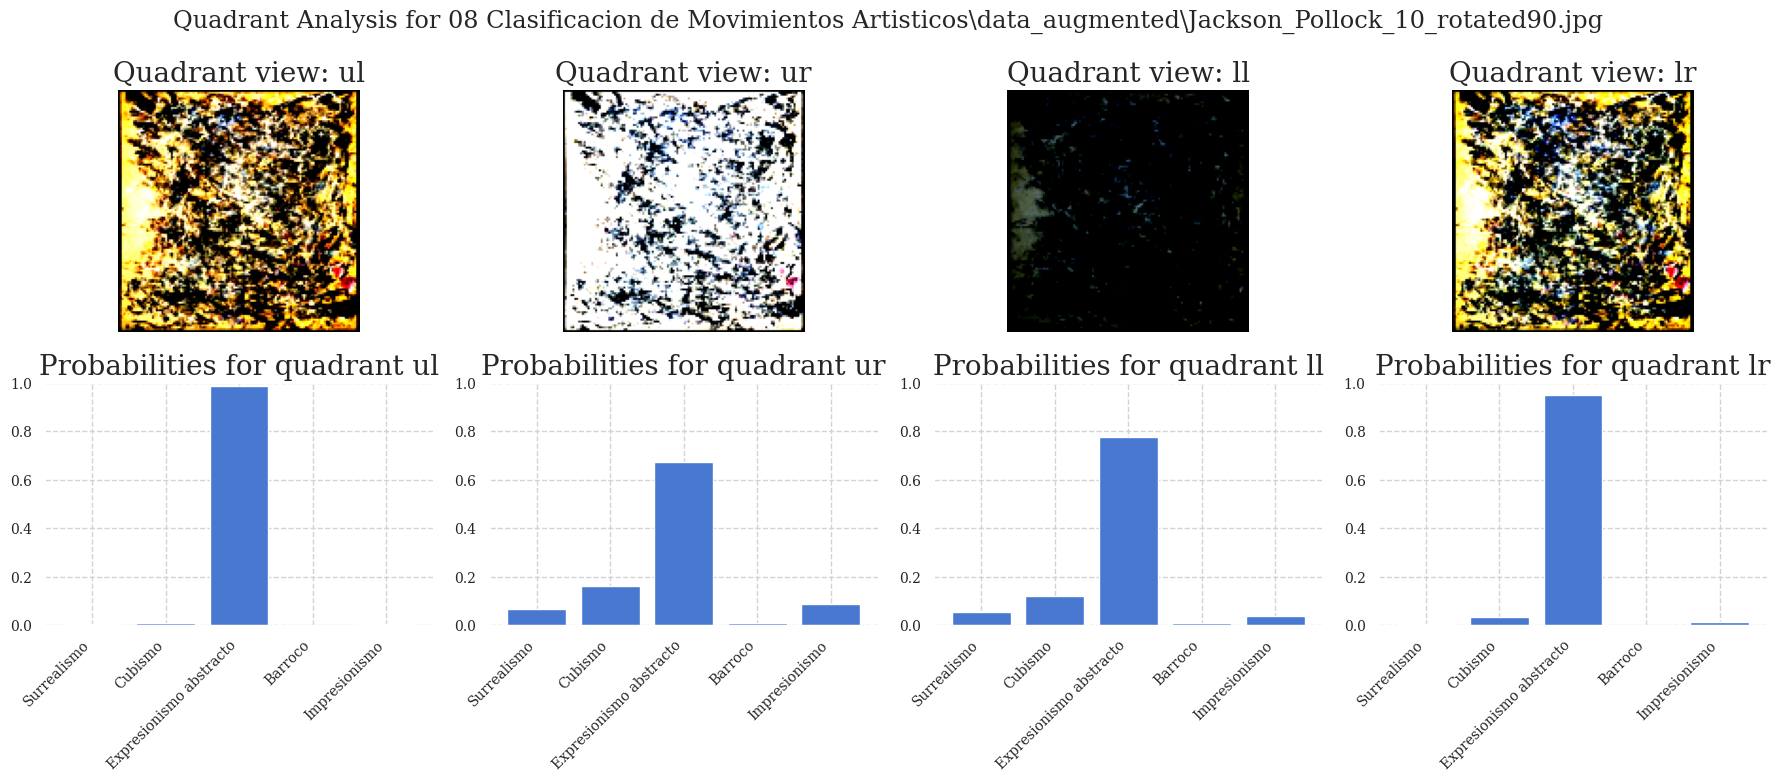

In [33]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

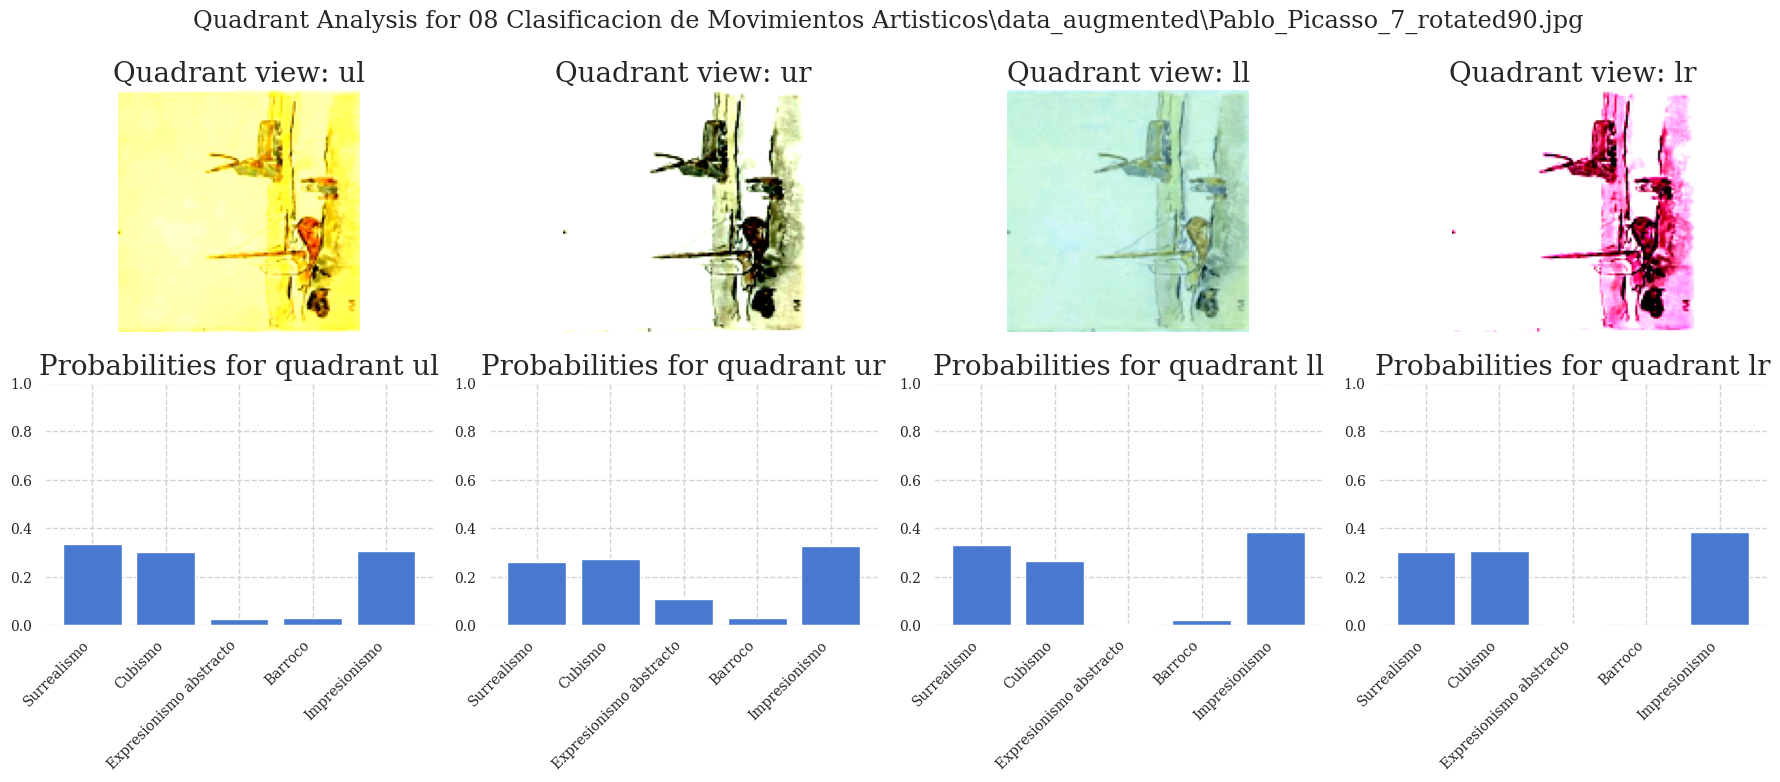

In [34]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

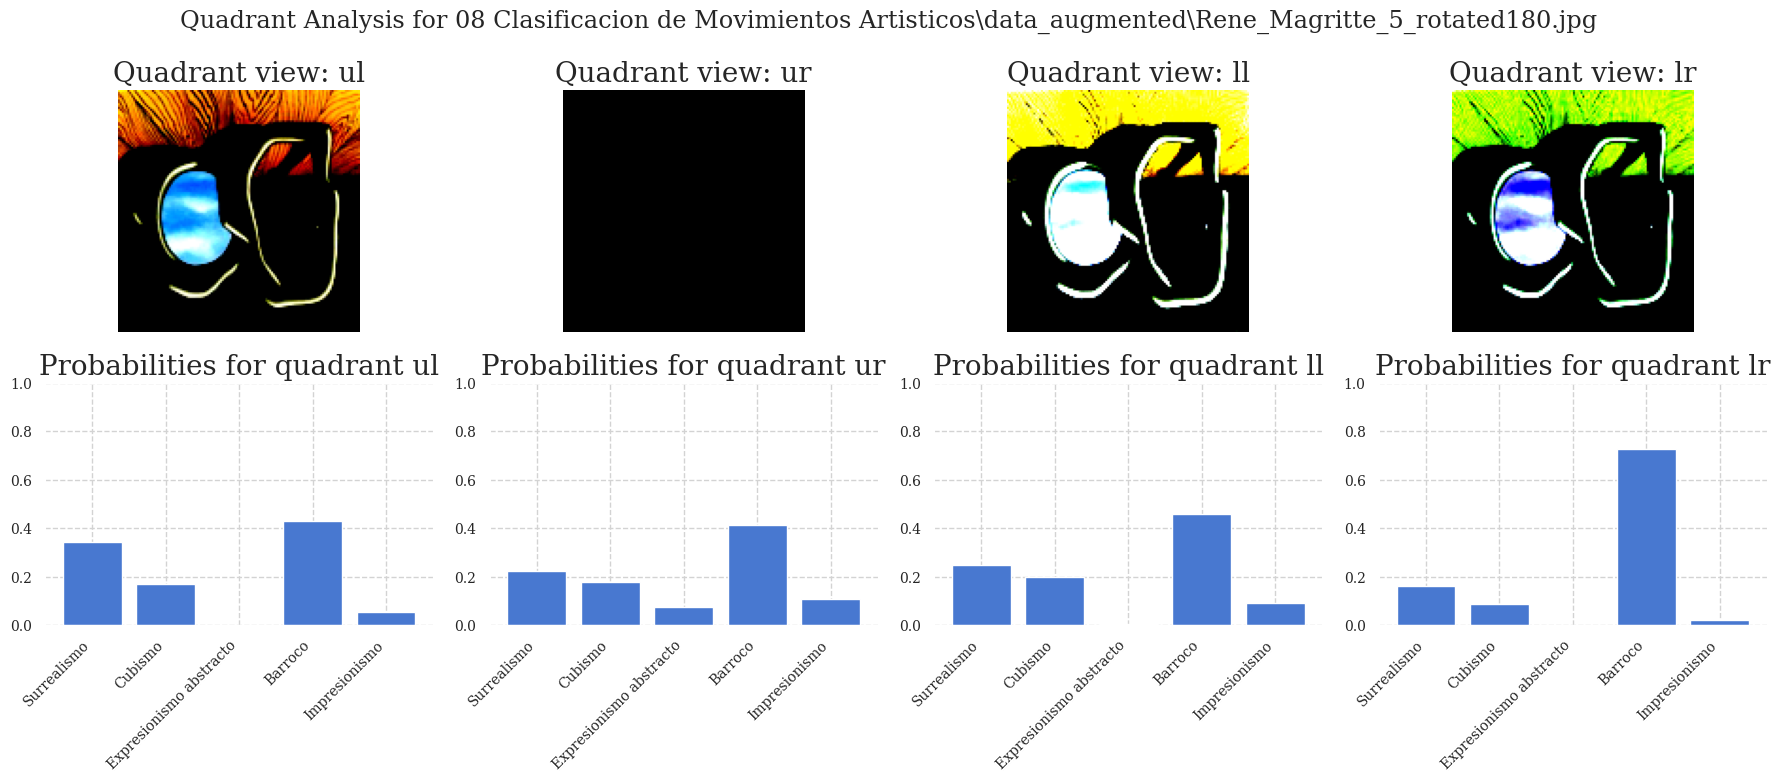

In [35]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

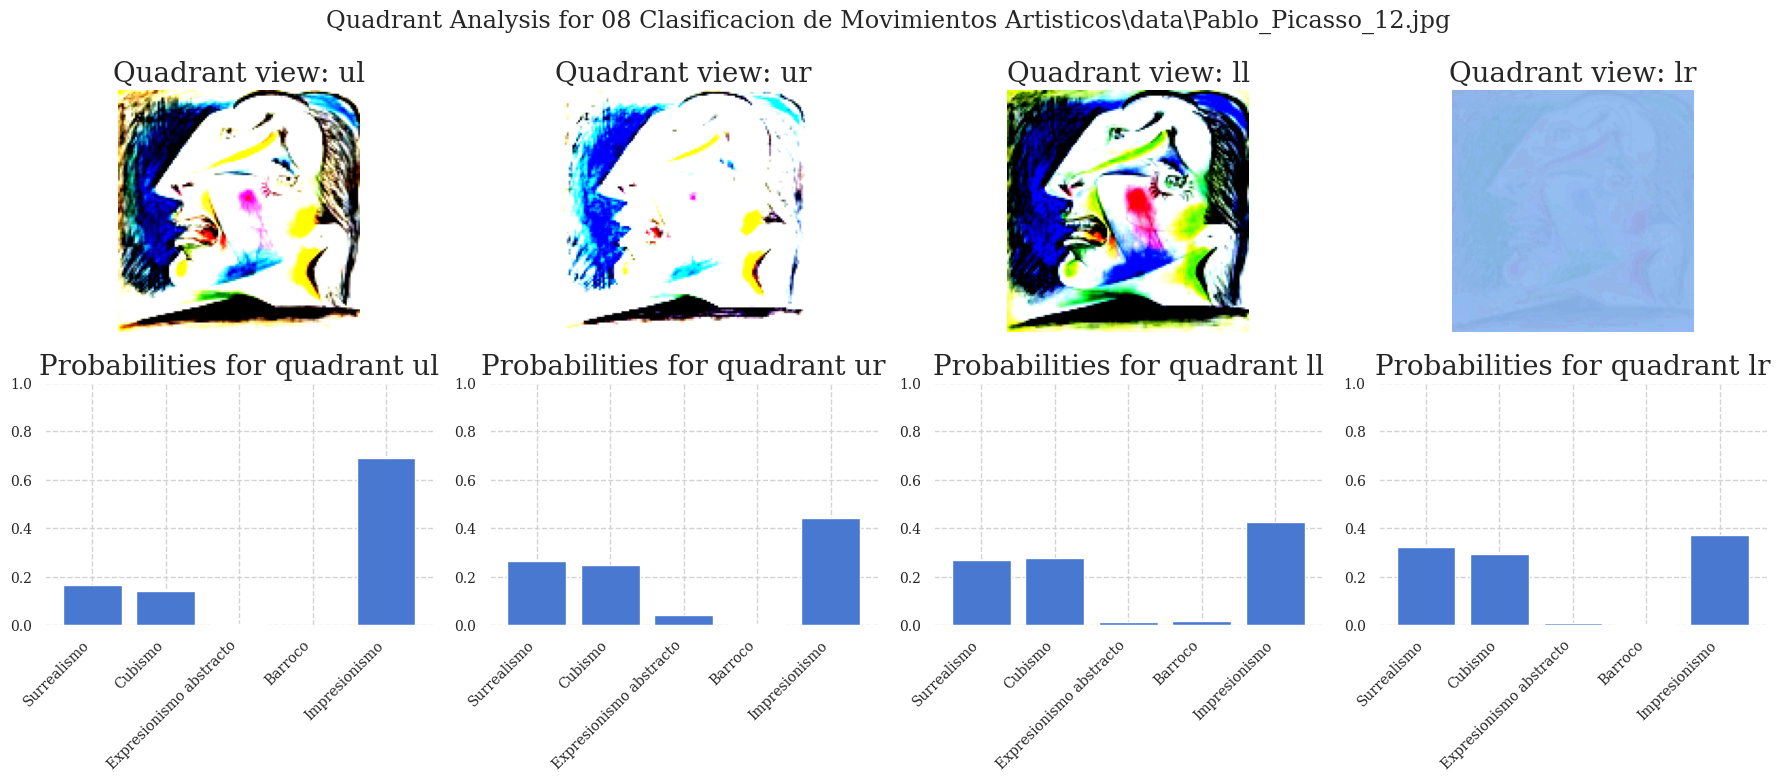

In [36]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

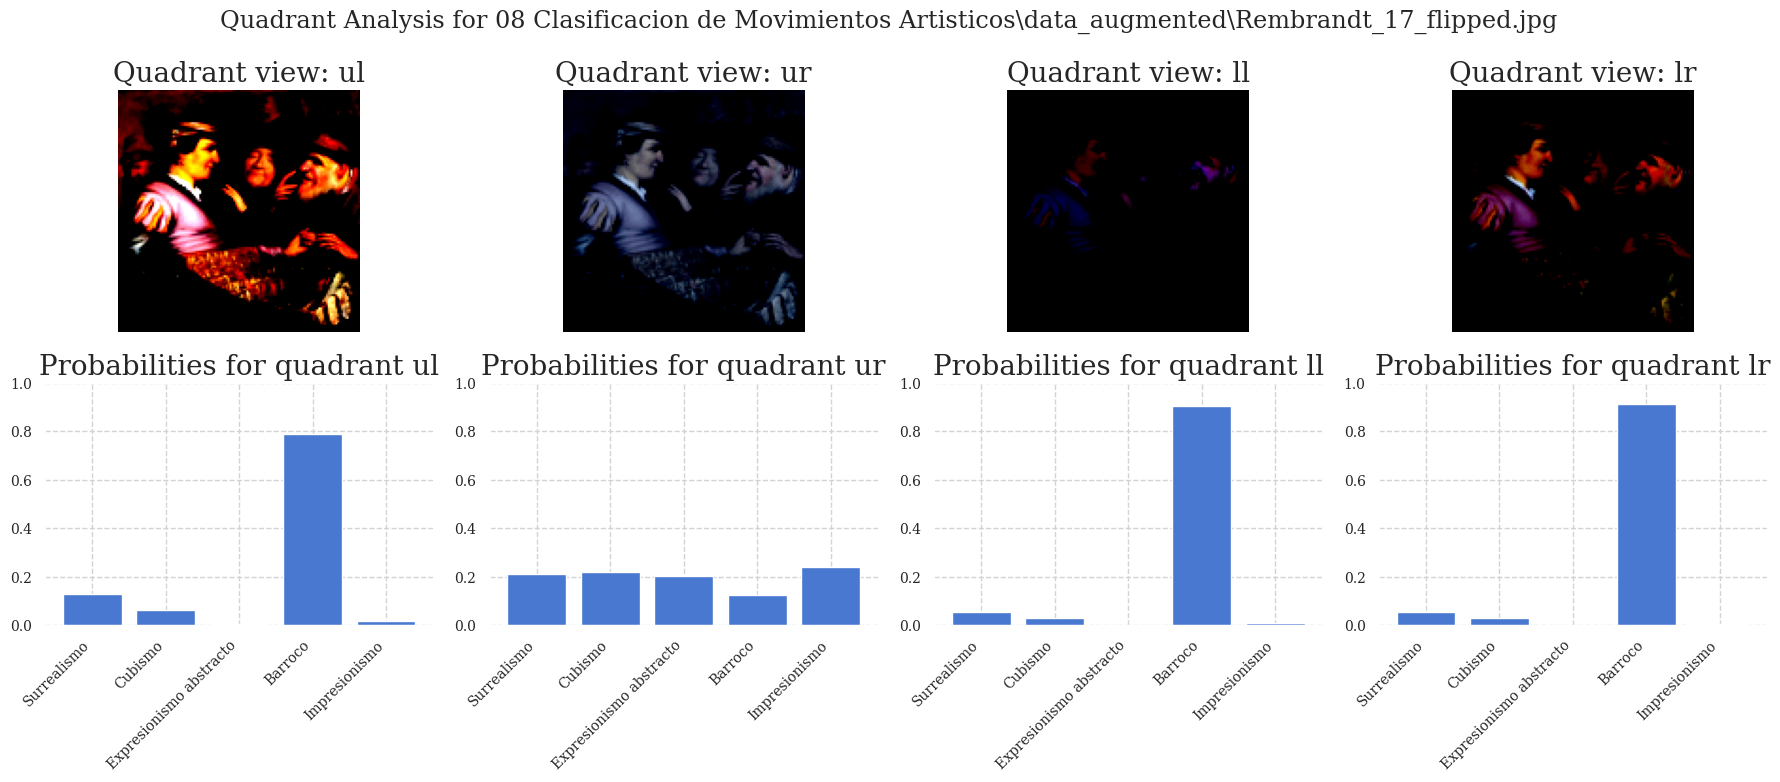

In [37]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

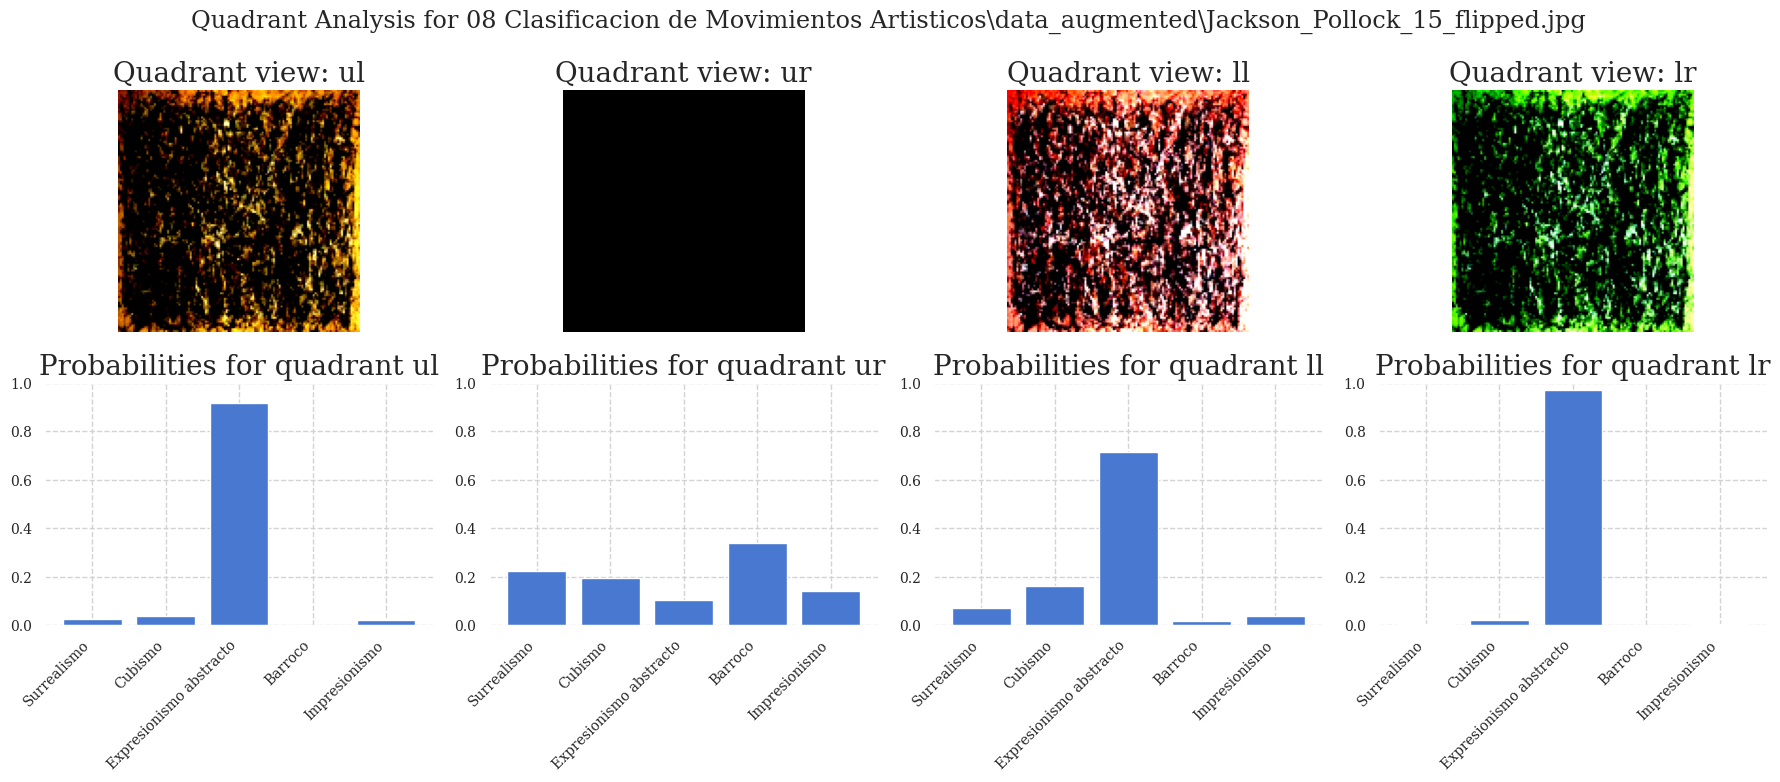

In [38]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

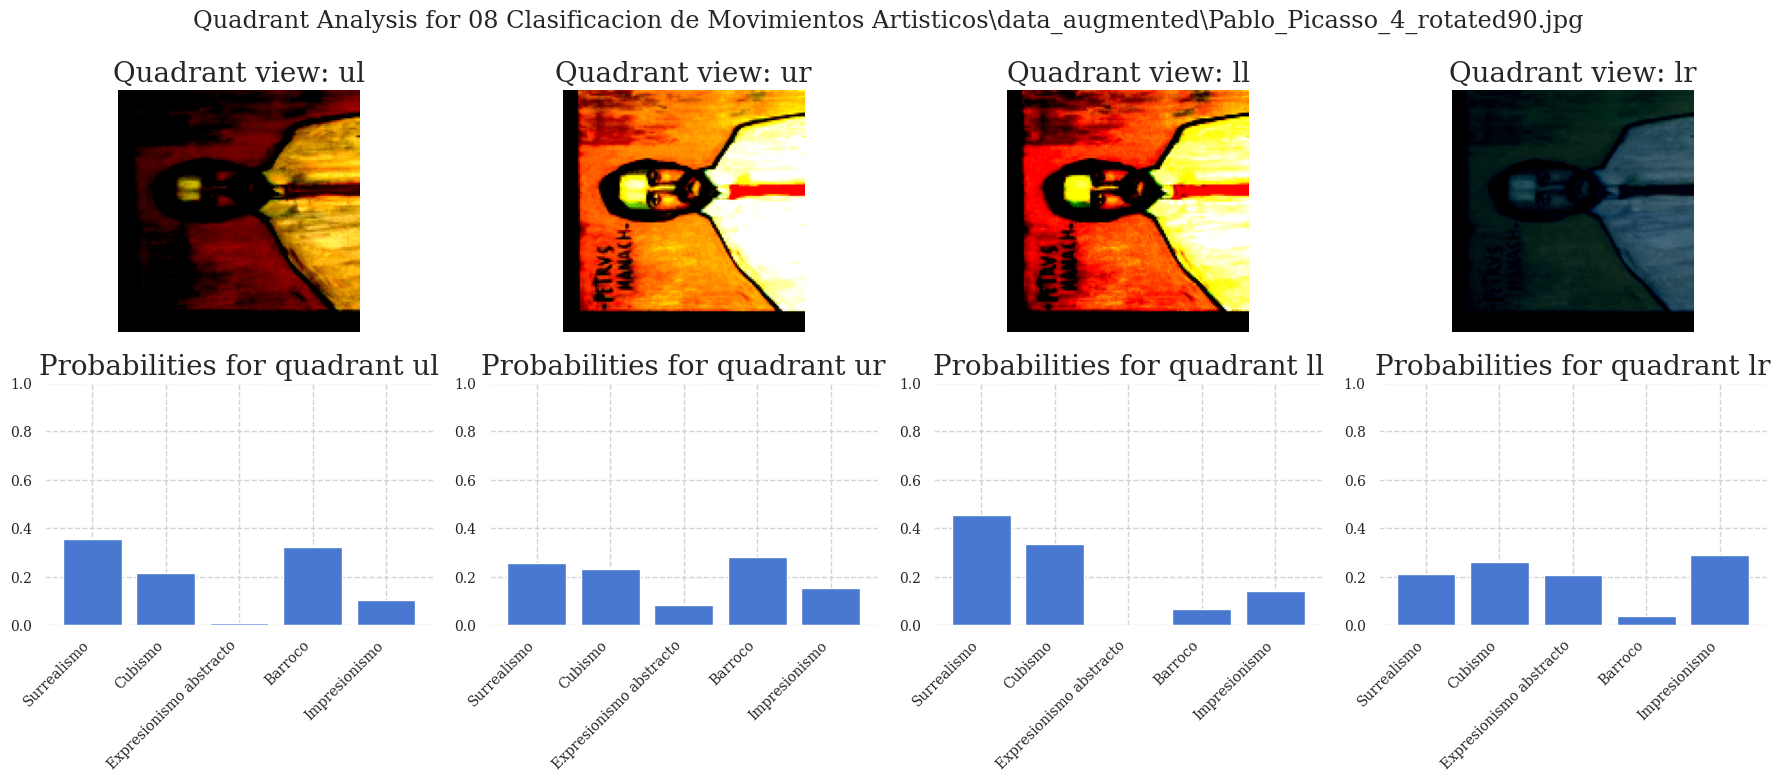

In [39]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

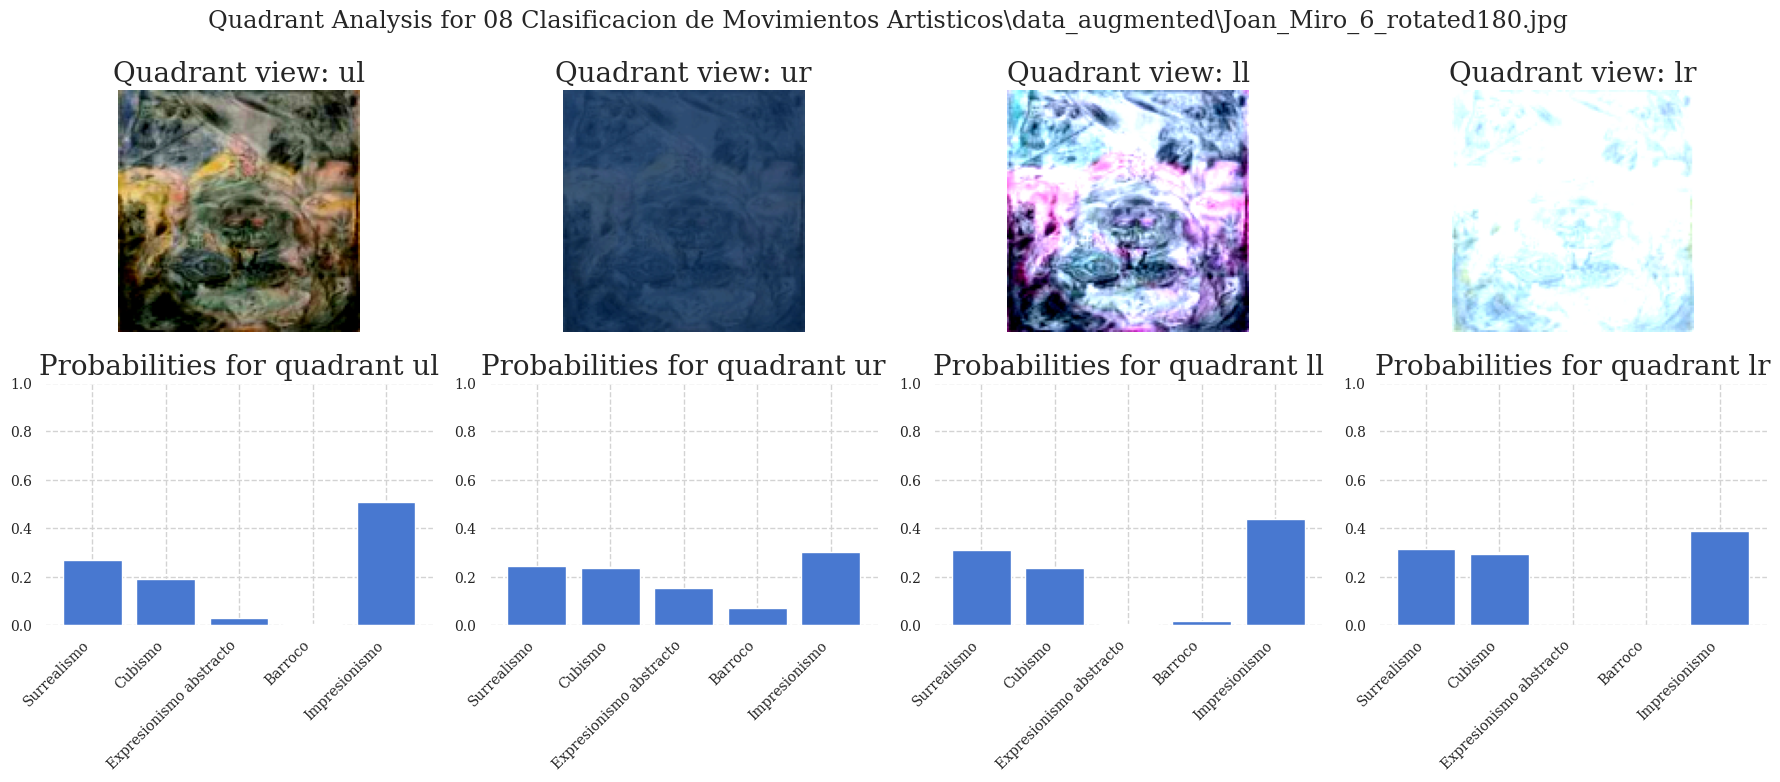

In [40]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

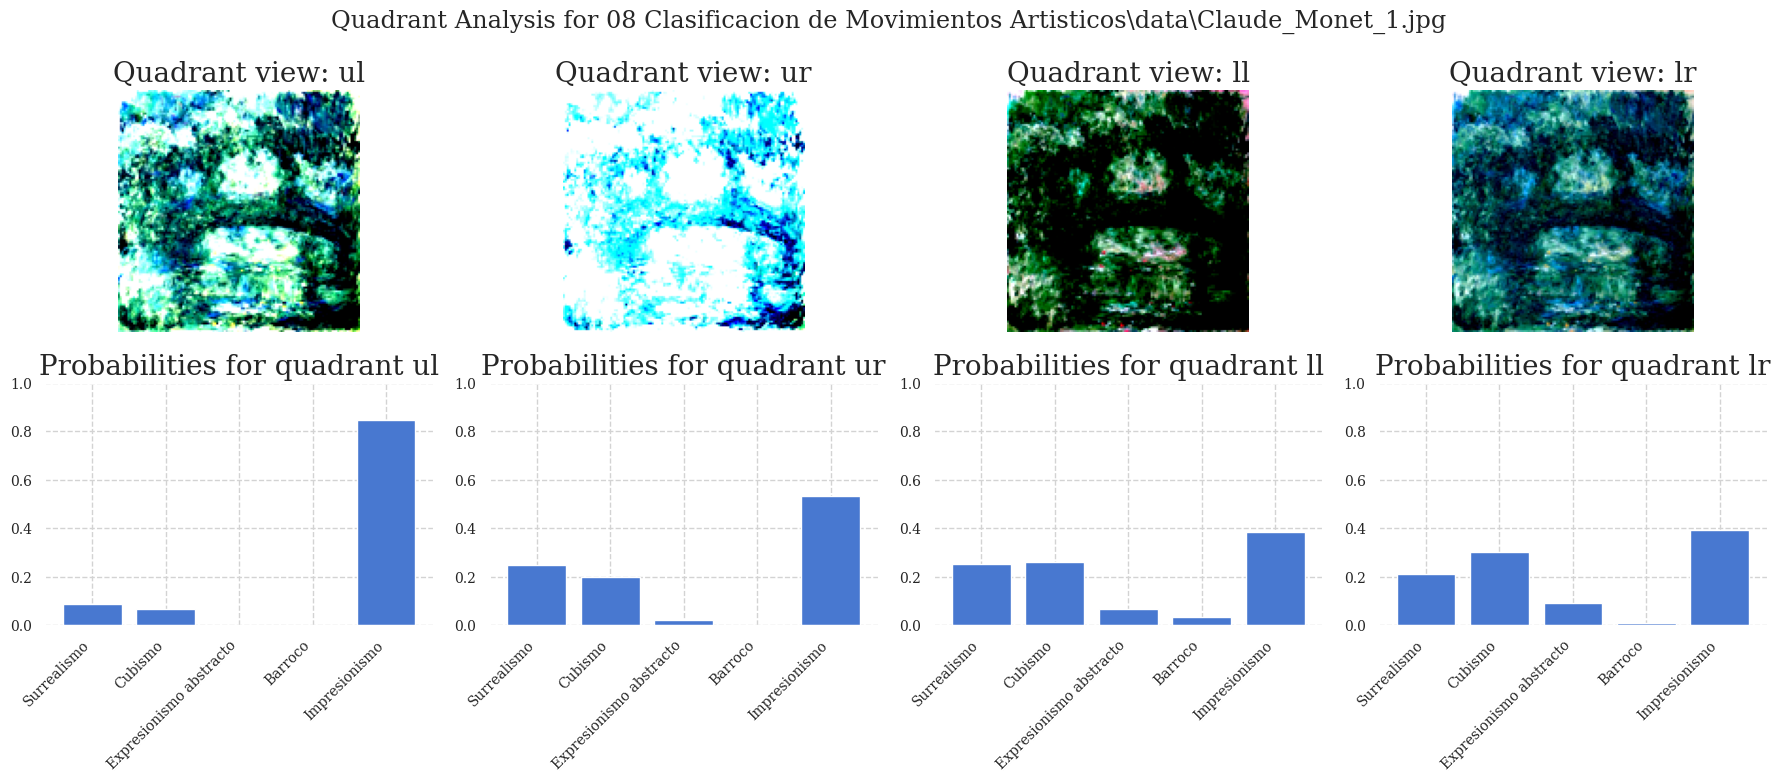

In [41]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

In [43]:
pred_idx, pred_probs = predict_full_pipeline(
    "08 Clasificacion de Movimientos Artisticos/bigbigbang/Alfred_Sisley_001.jpg",
    models_quadrant,
    transforms_quadrant,
    tpr_quadrant,
    rbf_meta_model,
)
print("Predicted:", inv_genre[pred_idx])
print("Probs:", pred_probs)


Predicted: Impresionismo
Probs: [0.2409537  0.2346149  0.12202156 0.1595775  0.24283233]


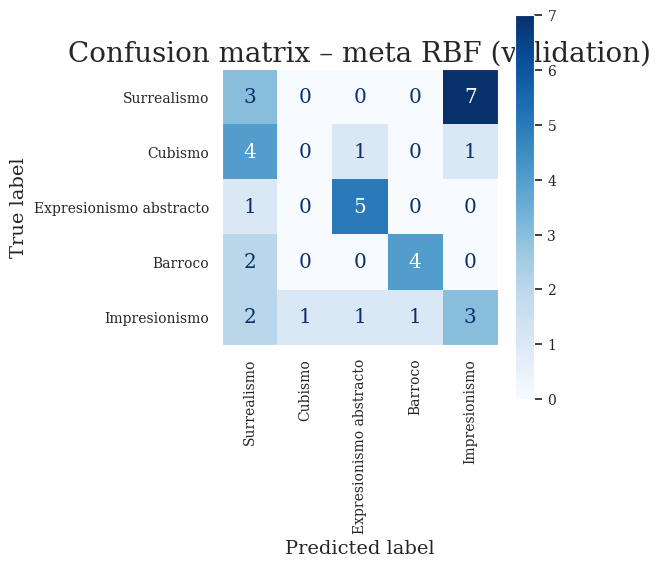

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) meta predictions on validation
rbf_meta_model.eval()
X_val_t = torch.tensor(X_val_meta, dtype=torch.float32).to(device)

with torch.no_grad():
    logits_val = rbf_meta_model(X_val_t)
    probs_val  = torch.softmax(logits_val, dim=1)
    y_pred_val = probs_val.argmax(dim=1).cpu().numpy()

# 2) confusion matrix
cm = confusion_matrix(y_val_meta, y_pred_val)
class_names = [inv_genre[i] for i in range(len(genre_to_label))]

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True)
ax.set_title("Confusion matrix – meta RBF (validation)")
plt.tight_layout()
plt.grid(False)
plt.show()


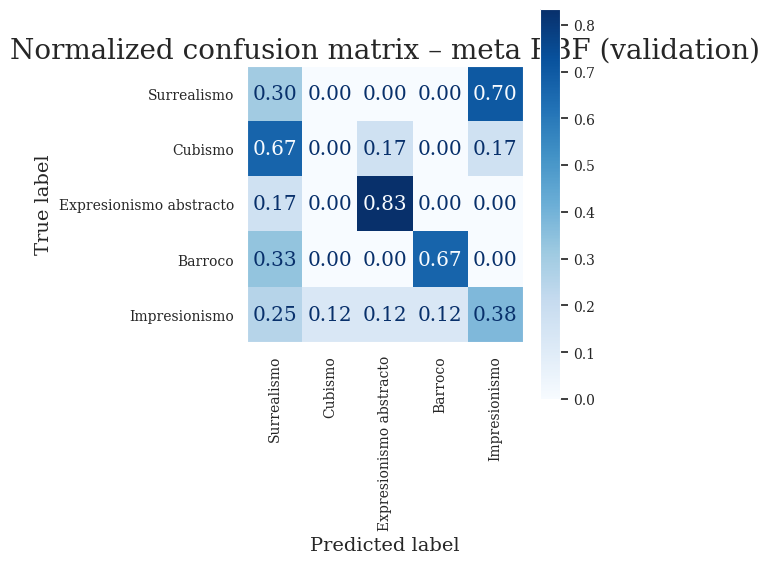

In [45]:
cm_norm = confusion_matrix(y_val_meta, y_pred_val, normalize="true")
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True, values_format=".2f")
ax.set_title("Normalized confusion matrix – meta RBF (validation)")
plt.tight_layout()
plt.grid(False)
plt.show()
